In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ct
from pytz import timezone

import sys
sys.path.append('../../../')

from utils.plot import config_matplotlib, figsize, fig_save_and_show, plot_events_data
from utils.optimization import MyOptimizationProblem, convert_to_model_params, plot_optimization_params, plot_optimization_error, plot_compare, compute_metrics, estimate_polynomial_coefficient_bounds, save_model_params_to_json, load_model_params_from_json
from utils.data import get_events, get_sections, load_df, process_df, export_dataframe_to_latex
from utils.sensitivity_analysis import describe_param_with_uniform_distribution, describe_param_with_log_uniform_distribution, describe_param_with_triangular_distribution, describe_param_with_normal_distribution, describe_param_with_truncated_normal_distribution, describe_param_with_log_normal_distribution, wrapped_model_function, create_problem_spec_and_sample, plot_sampled_distribuitions, evaluate_problem, analyze_time_step, analyze_problem, sobol_sensitivity_analysis_from_model_params_to_outputs, plot_sensitivity_analysis, plot_sensitivity_analysis_heatmaps, get_region_mean, plot_sensitivity_analysis_bars

import warnings
warnings.filterwarnings("ignore")

config_matplotlib()
latex_img_path = '/home/joaoantoniocardoso/workspace_TCC/repo/thesis/assets/generated/'
latex_tex_path = '/home/joaoantoniocardoso/workspace_TCC/repo/thesis/tex/generated/'

# Sensitivity Analysis

In [2]:
from model import Propulsion, get_hull_areas

Propulsion.build({})

<NonlinearIOSystem propulsion: ['batt_v', 'esc_d'] -> ['motor_v', 'motor_w', 'motor_i', 'motor_q_load', 'esc_i_in', 'prop_w', 'prop_j', 'prop_k_q', 'prop_k_t', 'prop_q', 'prop_t', 'prop_t_e', 'hull_u', 'hull_r_t']>

In [3]:
motor_params_loaded = load_model_params_from_json('../motor/me0909_free_rotor_step_params.json')
esc_params_loaded = load_model_params_from_json('../esc/mam17_params.json')

hull_M = 293.7 # [kg]
hull_S_water, hull_S_air = get_hull_areas(hull_M, hull_cog_x=1.9760, hull_S_total=8.2379)

propulsion_params = motor_params_loaded | esc_params_loaded | {
    'rho_water': 1023,  # Estimated from public ocean dataset
    'rho_air': 1.1839,  # Estimated from public ocean dataset
    'esc_tau_fall': 0.5,  # Unknown
    'esc_tau_rise': 1.5,  # Unknown
    'trans_eta': 0.9,  # Arbitrary
    'trans_I_r_in': 0,  # Ignored
    'trans_I_r_out': 0,  # Ignored
    'trans_k': 14/22,  # Manually counted
    'prop_D': 9.0 * 0.0254,  # From manufacturer's specs
    'prop_k_T_coeffs': np.array([ 0.37208208, -0.10825004, -0.16735476,  0.02821403]),
    'prop_k_Q_coeffs': np.array([ 0.05470368, -0.01753569, -0.00050999, -0.01078306]),
    'prop_eta_R': 1.0,  # Unknown
    'prop_I_r': 5.54e-04,  # Unknown
    'hull_C_T': 0.01,  # Unknown
    'hull_M': hull_M,  # Measured (fully loaded, with pilot)
    'hull_M_a': 0,  # Unknown
    'hull_S_water': hull_S_water,  # Estimated from hydrostatics
    'hull_S_air': hull_S_air,  # Estimated from hydrostatics
    'hull_T_ded': 0.0855,  # Estimated from models/2020/propeller/propeller.ipynb
    'hull_W': 0.1425,  # Estimated from models/2020/propeller/propeller.ipynb
}
propulsion_params

{'motor_B': 0.001401819826389131,
 'motor_I_r': 0.011815137847671575,
 'motor_I_r_load': 0,
 'motor_K_Q': 0.10638460838741098,
 'motor_K_V': 0.10178006369696158,
 'motor_L_A': 6.24949639106588e-05,
 'motor_R_A': 0.0195442230227981,
 'esc_E_off': 0.00011,
 'esc_E_on': 7e-05,
 'esc_F_s': 12550,
 'esc_Q_rr': 1.9e-07,
 'esc_R_ds_on': 0.006428129677311848,
 'esc_V_F': 2.884681806089211,
 'esc_V_ds_ov': 1.2222222222222223,
 'esc_R_D': 0.003448696395697723,
 'rho_water': 1023,
 'rho_air': 1.1839,
 'esc_tau_fall': 0.5,
 'esc_tau_rise': 1.5,
 'trans_eta': 0.9,
 'trans_I_r_in': 0,
 'trans_I_r_out': 0,
 'trans_k': 0.6363636363636364,
 'prop_D': 0.2286,
 'prop_k_T_coeffs': array([ 0.37208208, -0.10825004, -0.16735476,  0.02821403]),
 'prop_k_Q_coeffs': array([ 0.05470368, -0.01753569, -0.00050999, -0.01078306]),
 'prop_eta_R': 1.0,
 'prop_I_r': 0.000554,
 'hull_C_T': 0.01,
 'hull_M': 293.7,
 'hull_M_a': 0,
 'hull_S_water': 4.050226176680205,
 'hull_S_air': 4.187673823319795,
 'hull_T_ded': 0.0855,

In [4]:
def model_function(T, U, X0, **params):
    return ct.input_output_response(
        Propulsion.build(params=params),
        T=T,
        U=U,
        X0=X0,
        solve_ivp_method='Radau',
        # solve_ivp_kwargs=dict(max_step=1),
    ).to_pandas()

def propulsion_sensitivity_analysis_step_response(
    params_description: dict,
    voltage_step: float,
    duty_cycle_step: float,
    samples: int,
    do_plot=True,
    calc_second_order=True,
    nprocs: int = 4,
):

    model_class = Propulsion
    model_params = propulsion_params
    model_tmp = model_class.build(model_params)

    # Time array
    T = np.linspace(0, 10, 11, endpoint=True)

    # Input data
    U = np.empty([model_tmp.ninputs, len(T)]) * np.nan # type: ignore ; obs: the "nan" here is to force us to define every input
    U[model_tmp.input_labels.index('batt_v')] = voltage_step
    U[model_tmp.input_labels.index('esc_d')] = duty_cycle_step

    # Initial state
    X0 = model_class.initial_state(
        X0=dict(),
        U0=U[:,0],
        params=model_params,
    )

    df_sa, problem = sobol_sensitivity_analysis_from_model_params_to_outputs(
        params_description=params_description,
        T=T,
        U=U,
        X0=X0,
        model_function=model_function,
        model_class=model_class,
        model_params=model_params,
        samples=samples,
        calc_second_order=calc_second_order,
        seed=42,
        nprocs=nprocs,
    )

    df_steady_state_mean = get_region_mean(df_sa, t_start=8, t_end=10)
    df_steady_state_mean = df_steady_state_mean.dropna(subset=['value', 'conf'])
    valid_outputs = sorted(df_steady_state_mean.reset_index()['output'].unique())

    export_dataframe_to_latex(
        filename=f"{latex_tex_path}/propulsion_sensitivity_analysis.tex",
        label=f'table:propulsion_sensitivity_analysis',
        caption='Índices de Sobol em regime permanente',
        df_steady_state_mean=df_steady_state_mean,
    )

    if do_plot:
        display(df_steady_state_mean)

        # fig_save_and_show(
        #     None,
        #     'Distribuição dos valores para cada fator',
        #     'Distribution of the values for each factor',
        #     fig=plot_sampled_distribuitions(problem),
        #     ncols=3,
        # )

        # for output in df_sa['output'].unique():
        #     fig_save_and_show(
        #         None,
        #         f'Índices de Sobol para a saída {output} durante o tempo',
        #         f'Sobol Indices for the output {output} over time\nwith step of {duty_cycle_step*100} [\%] and {voltage_step} [V],\nwith {samples} samples',
        #         fig=plot_sensitivity_analysis(df_sa, output=output),
        #         ncols=3,
        #     )

        # for output in df_sa['output'].unique():
        #     fig_save_and_show(
        #         None,
        #         f'Índices de Sobol para a saída {output} durante o tempo',
        #         f'Sobol Indices for the output {output} over time\nwith step of {duty_cycle_step*100} [\%] and {voltage_step} [V],\nwith {samples} samples',
        #         fig=plot_sensitivity_analysis_heatmaps(df_sa, output=output),
        #         ncols=3,
        #     )

        for output in valid_outputs:
            fig_save_and_show(
                f'{latex_img_path}/propulsion_sensitivity_analysis_{output}.pdf',
                f'Índices de Sobol para a saída {output} em regime permanente',
                f'Sobol Indices for the output {output} at steady-state\nwith step of {duty_cycle_step*100} [%] and {voltage_step} [V],\nwith {samples} samples',
                fig=plot_sensitivity_analysis_bars(df_steady_state_mean, output=output),
                ncols=3,
            )

    return df_sa, problem


pool


chain


value          conf
output   factor          metric                            
esc_i_in wake_deduction  S1      1.246194e-03  8.662666e-04
                         ST      1.656162e-03  9.733624e-05
         prop_inertia    S1      3.148909e-06  1.012380e-05
                         ST      1.917336e-07  4.258576e-08
         prop_efficiency S1      9.981428e-01  3.625770e-02
...                                       ...           ...
prop_w   prop_efficiency ST      9.977764e-01  1.568742e-02
         hull_drag       S1      3.221462e-04  6.063116e-04
                         ST      9.062282e-04  8.866525e-05
         hull_added_mass S1     -3.703135e-05  3.779622e-04
                         ST      2.144225e-04  3.825367e-05

[130 rows x 2 columns]

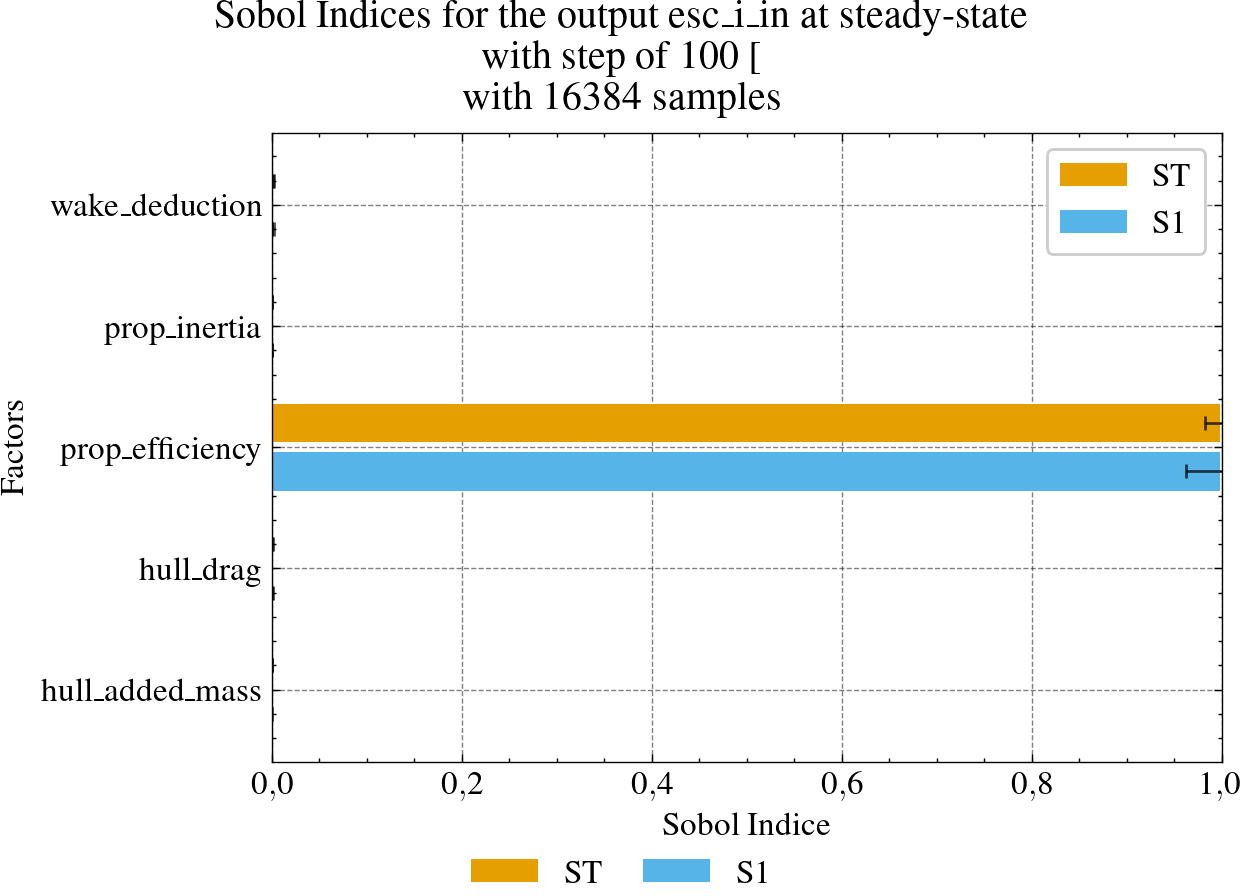

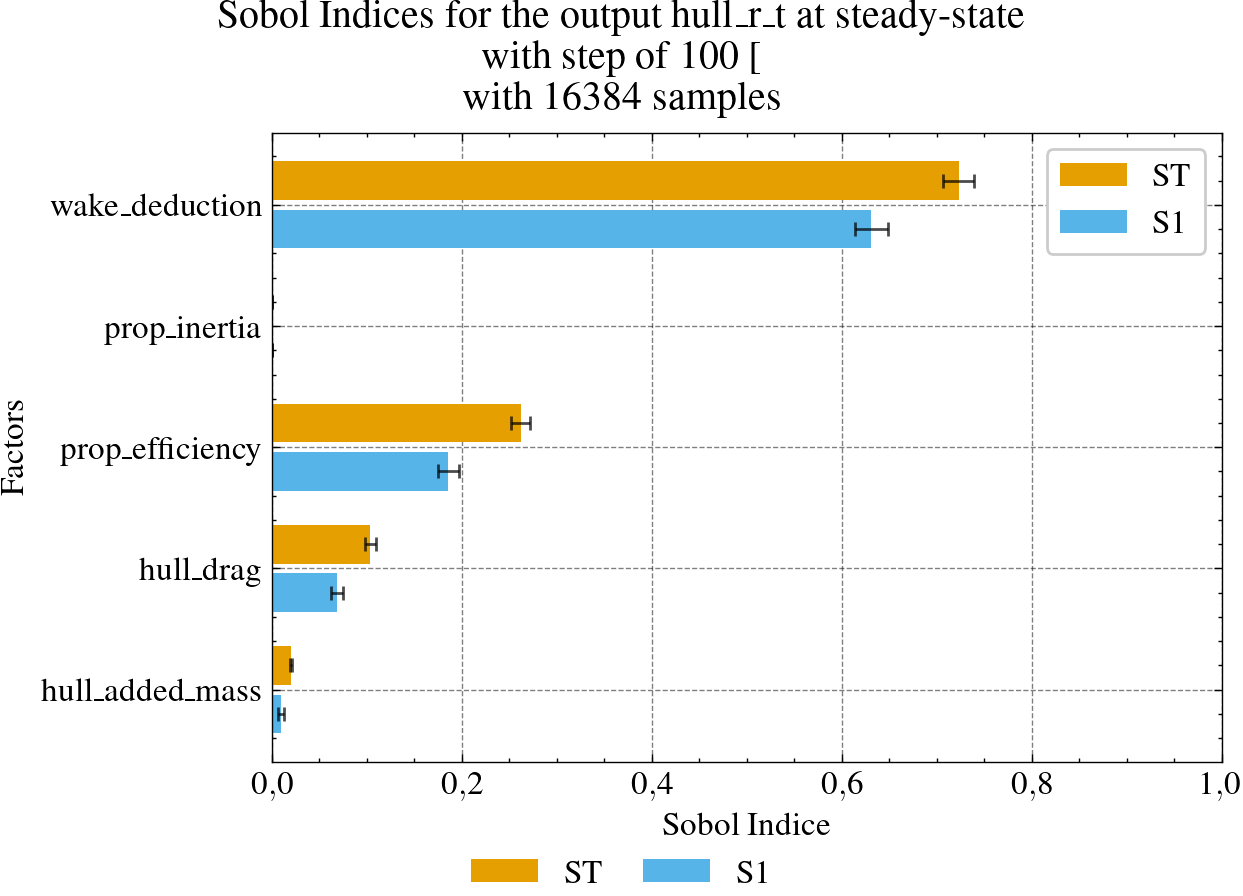

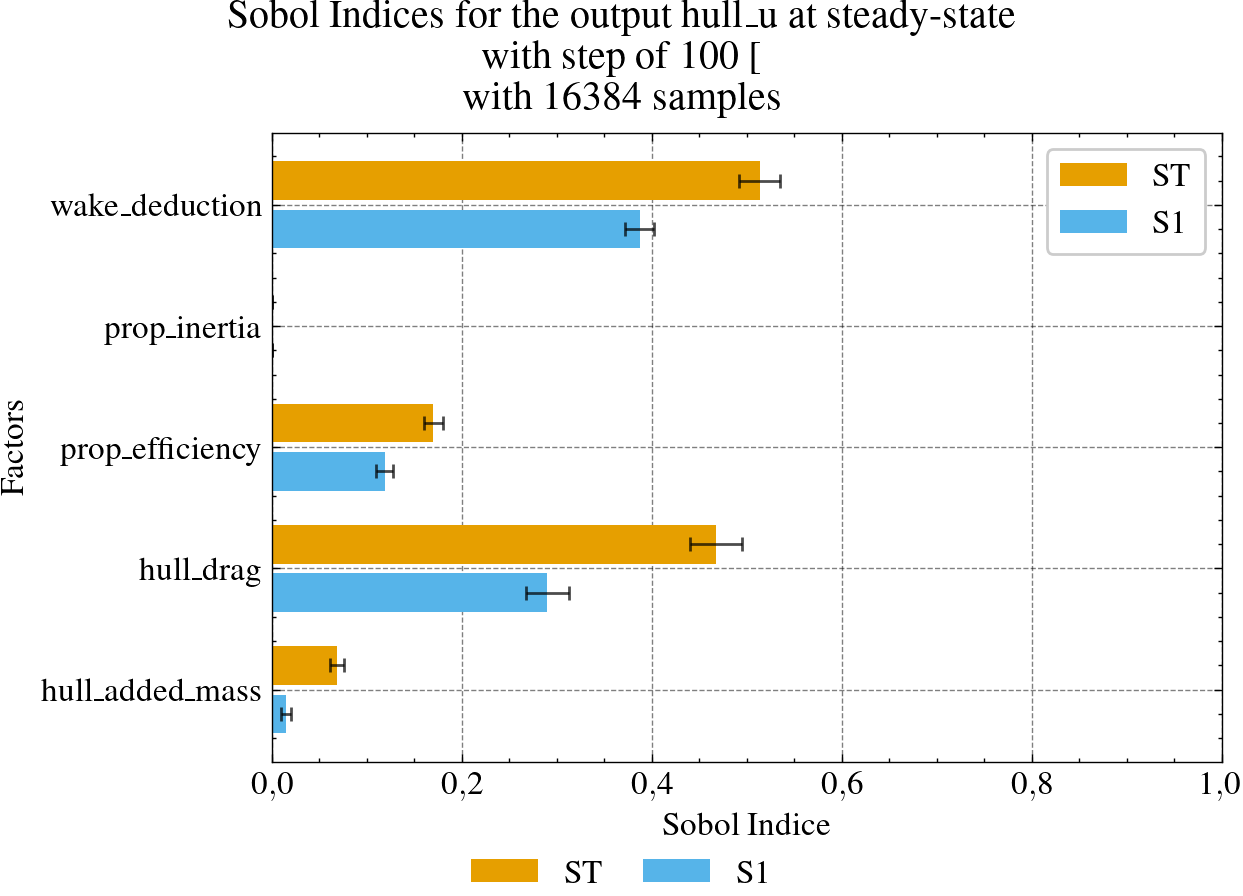

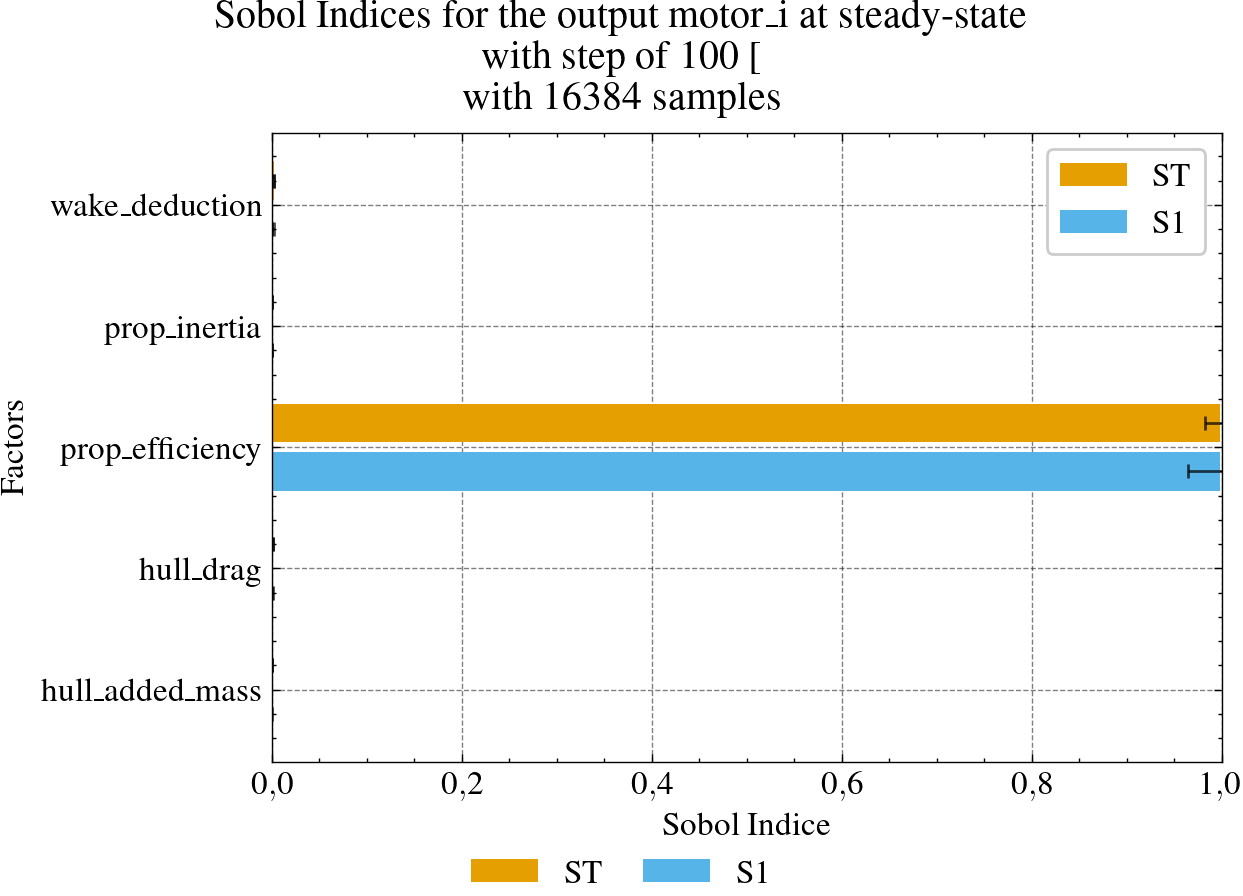

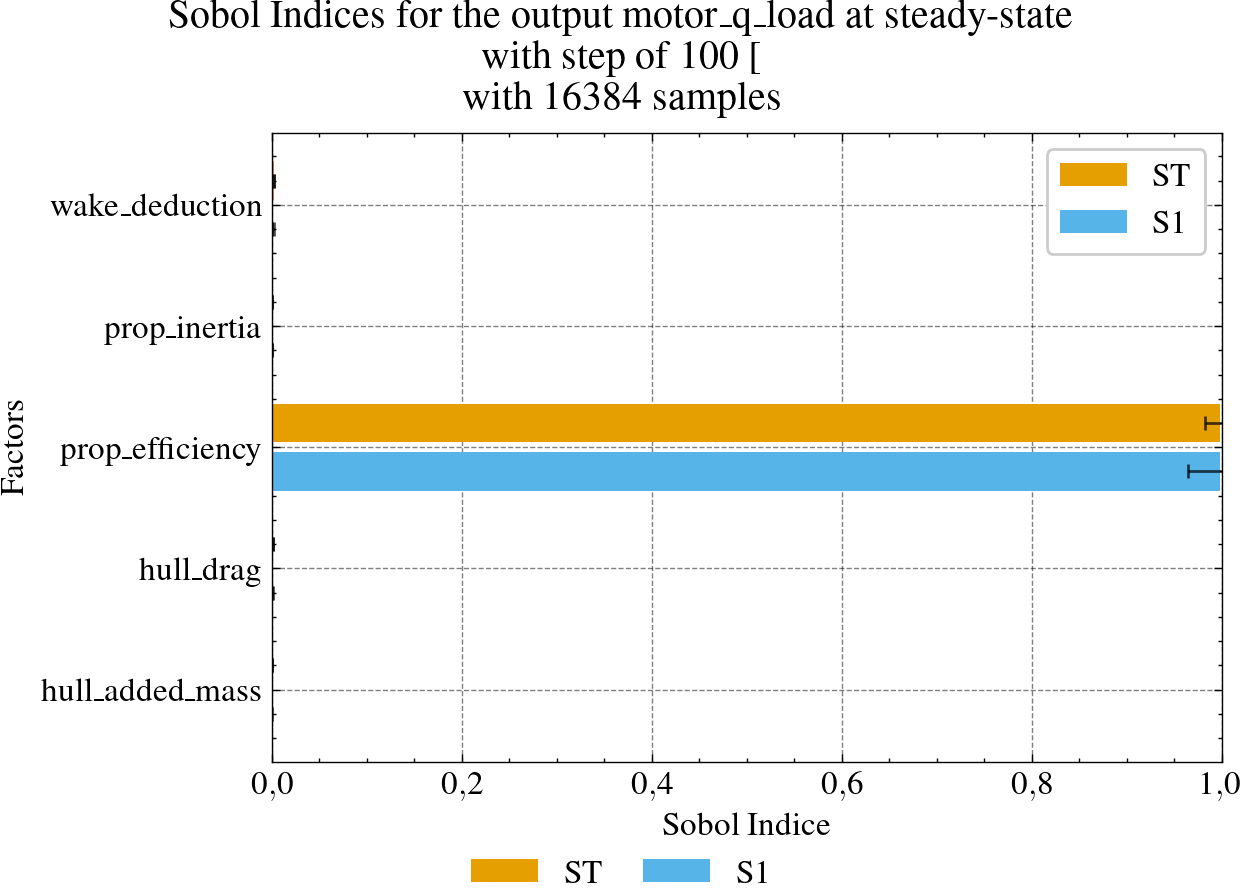

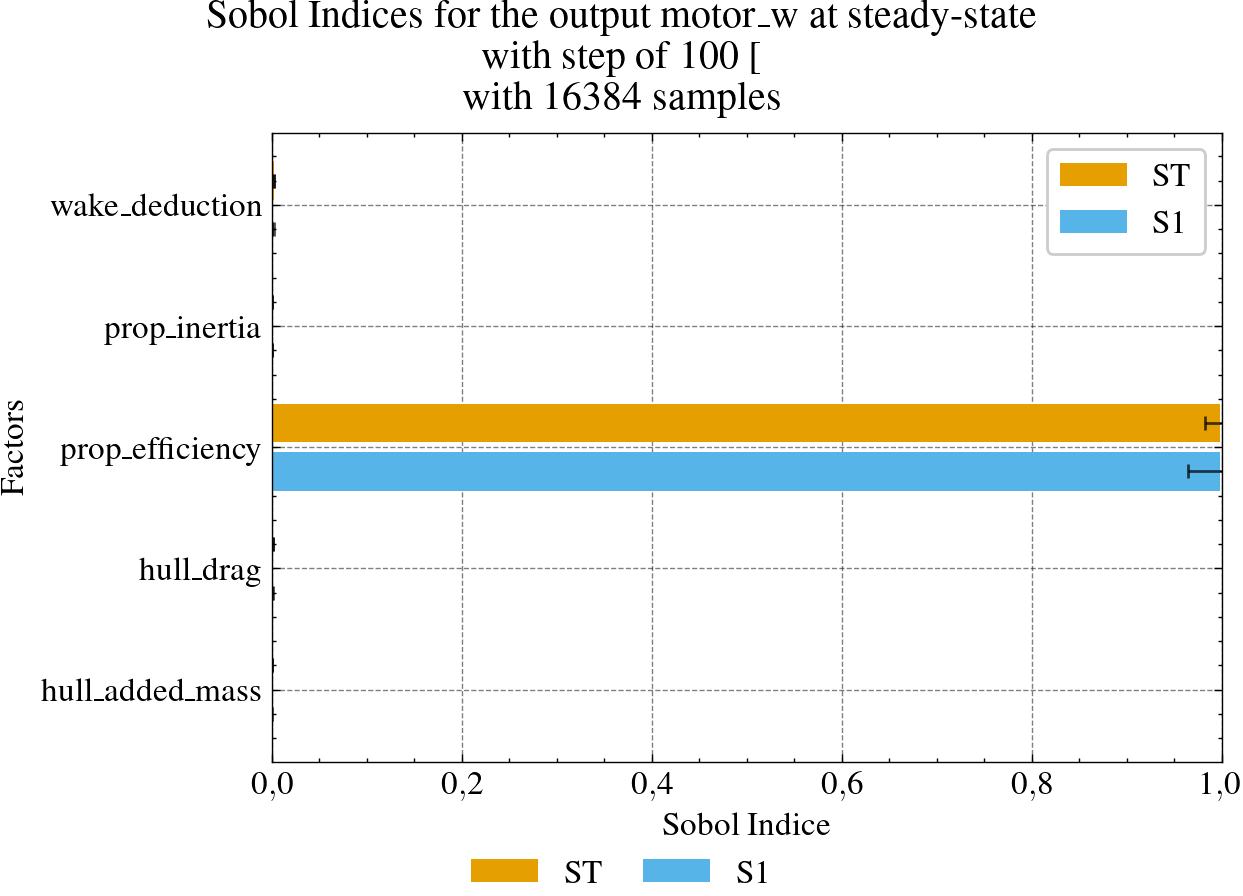

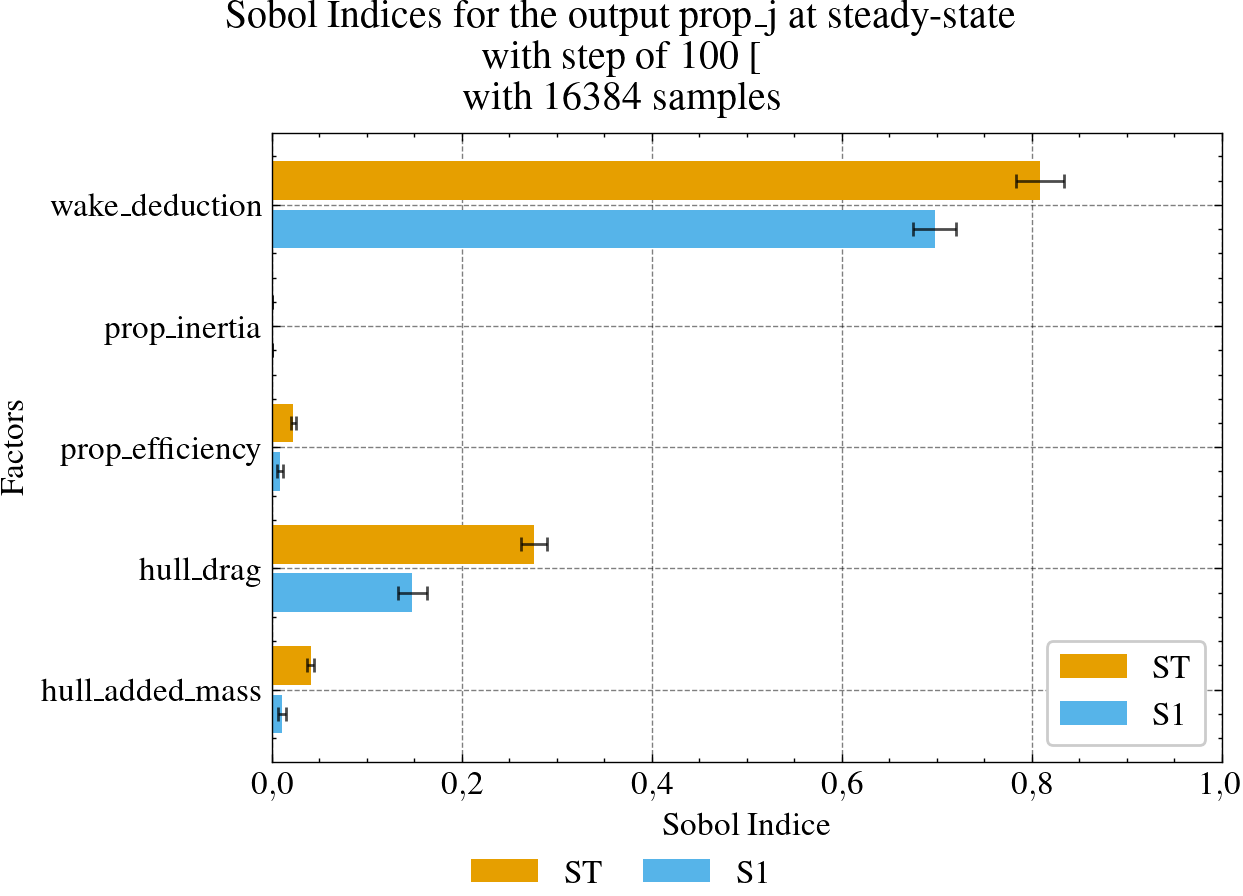

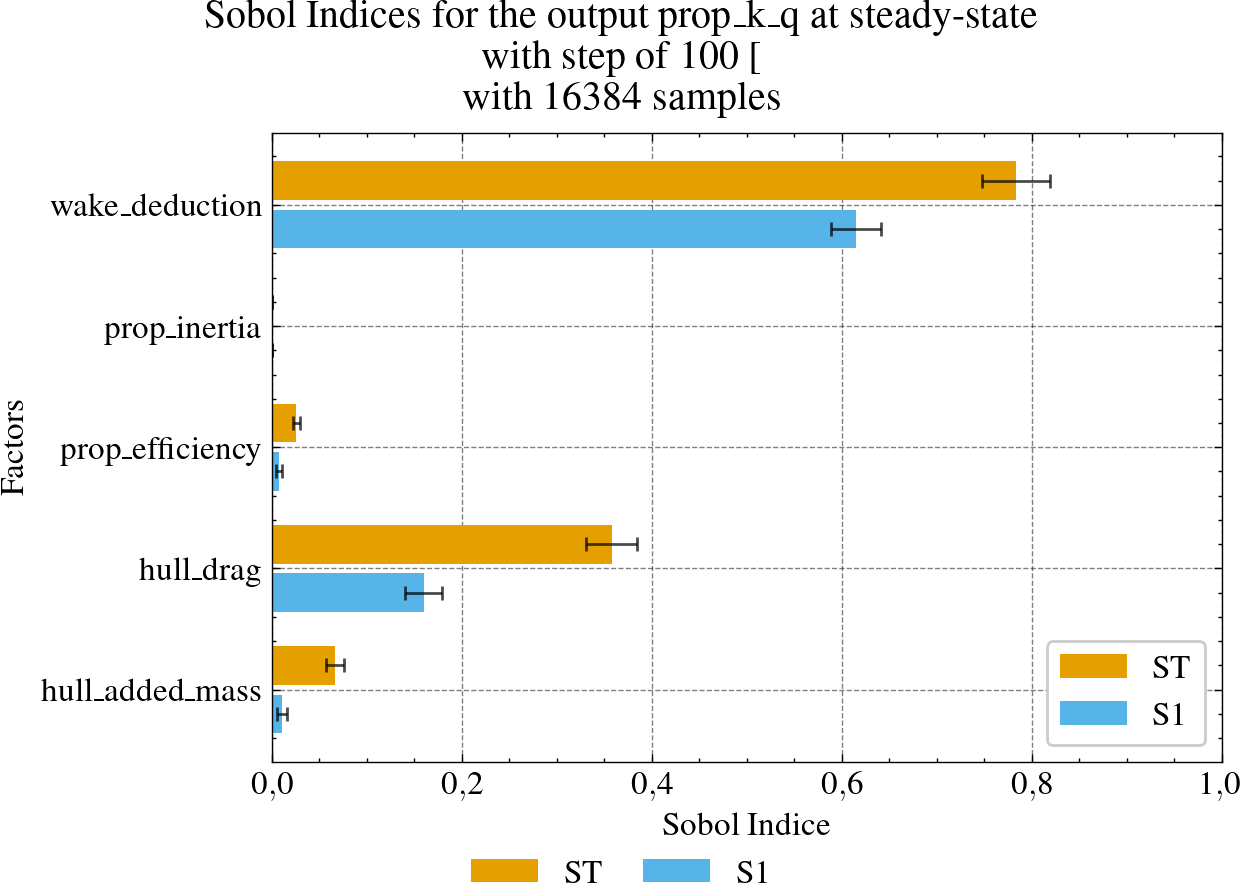

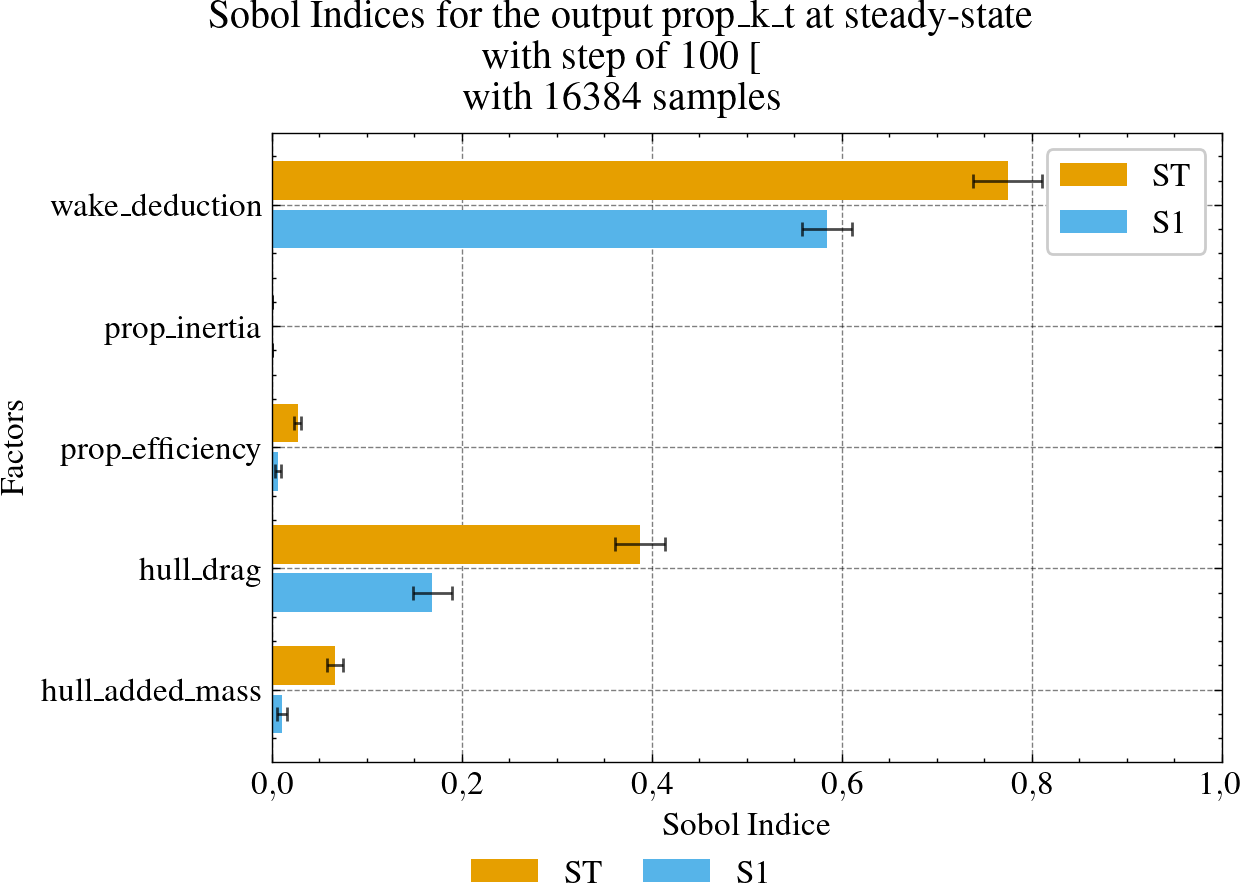

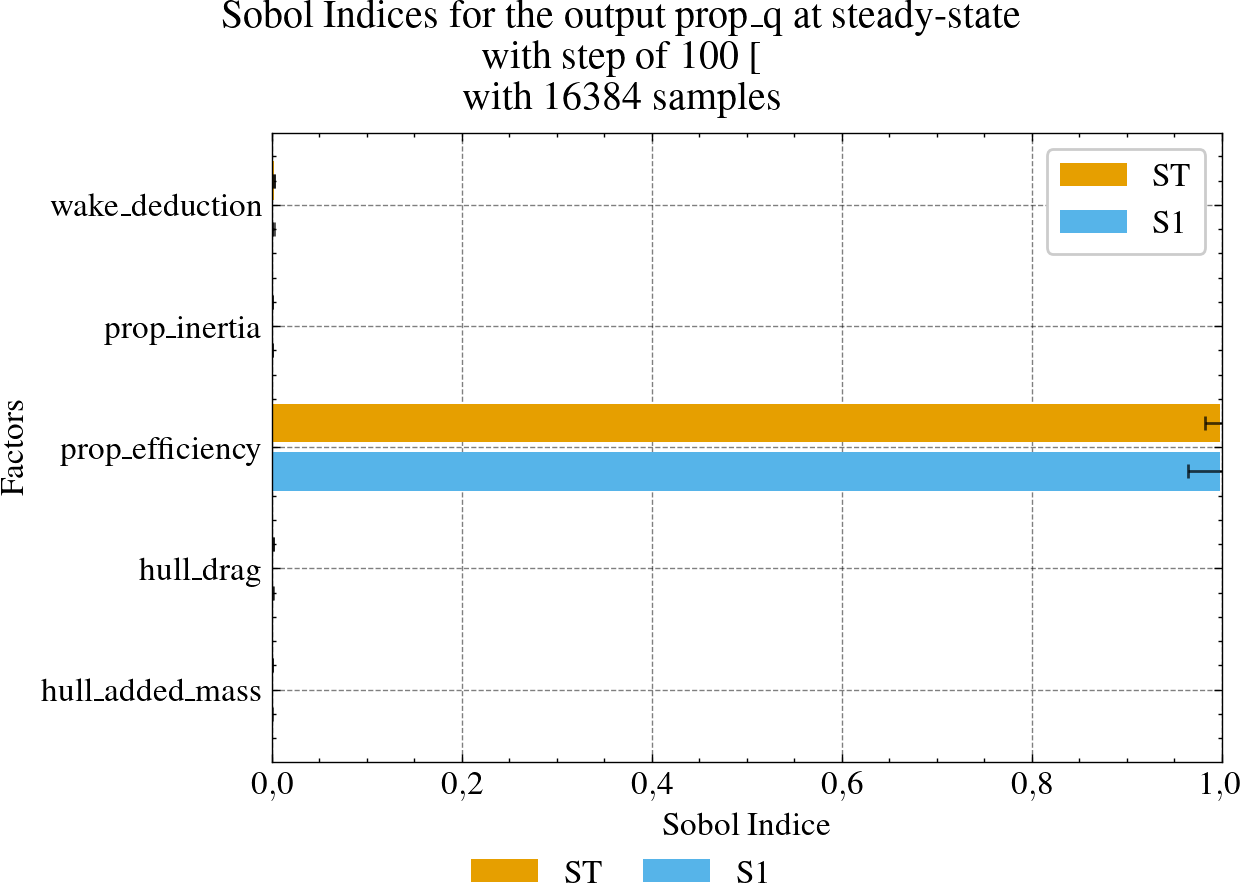

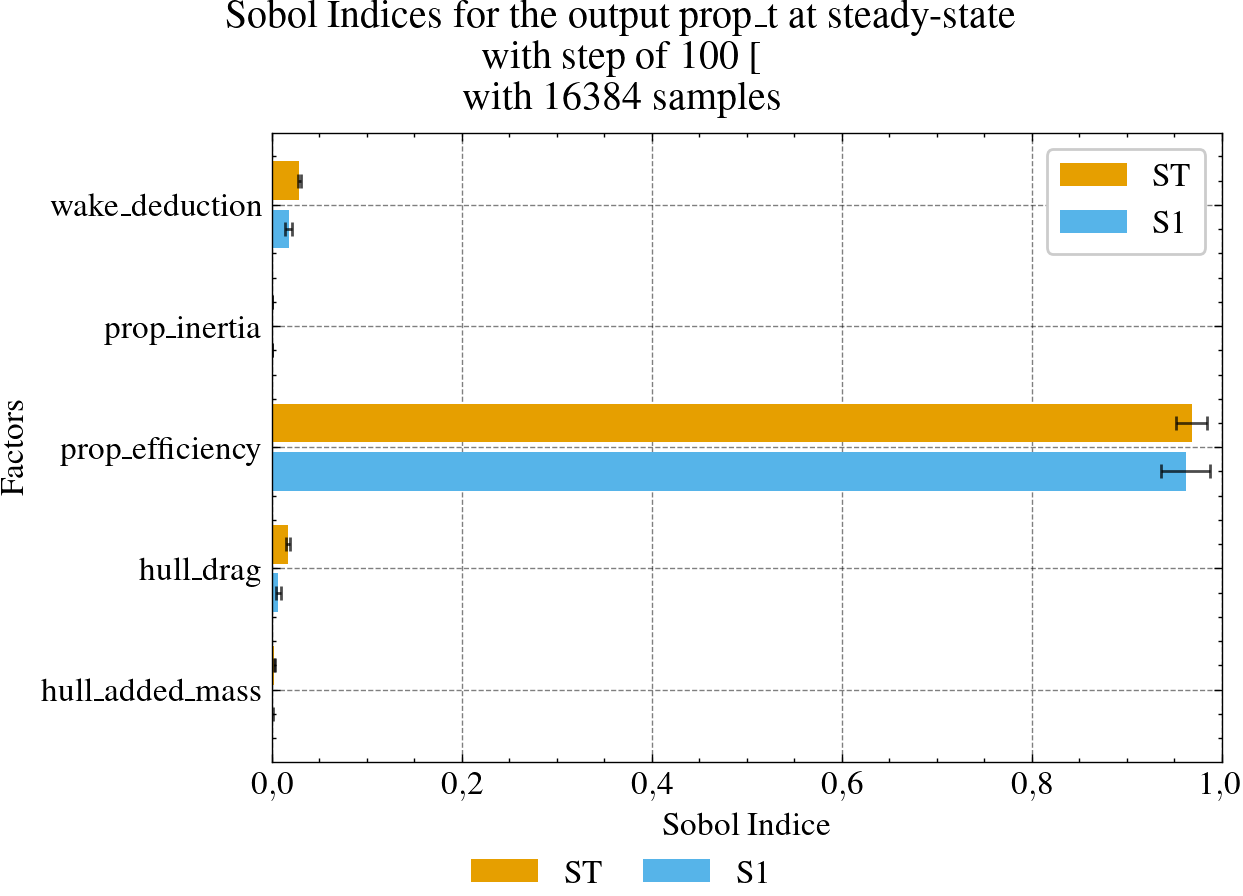

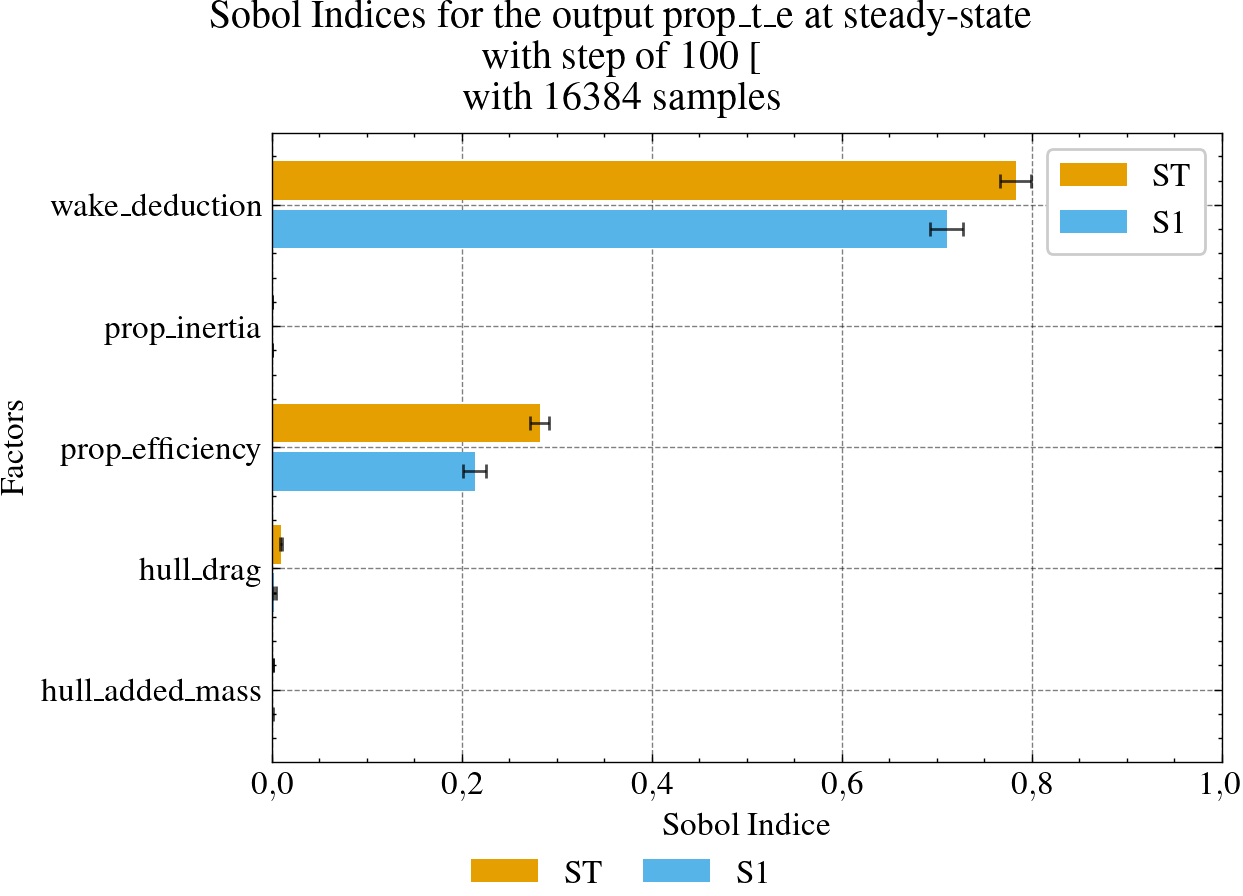

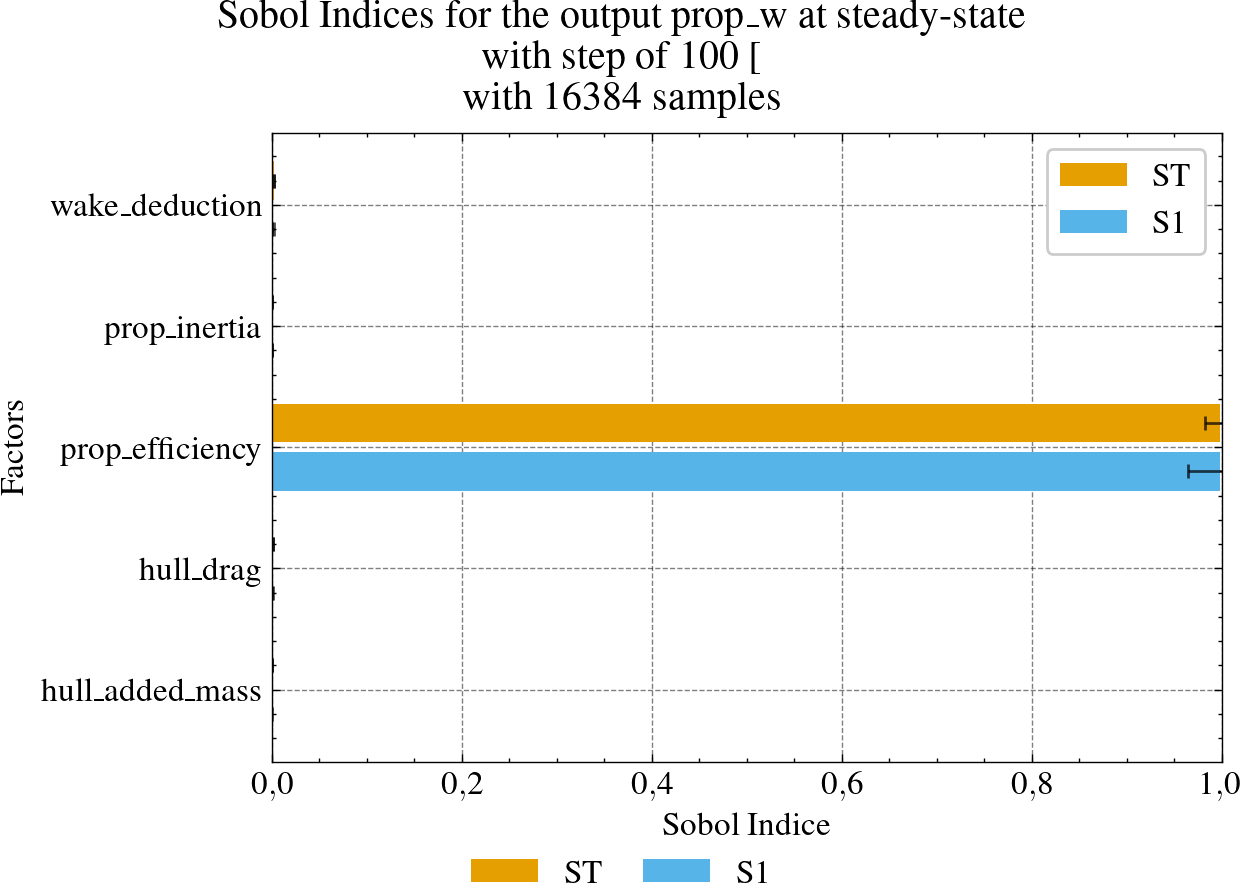

In [5]:
# Sensitivity analysis aligned with the propulsion optimization decision variables
# and expanded to five groups for better visualization.
params_description = {
    'hull_C_T': describe_param_with_uniform_distribution(lower=0.0, upper=0.1, group='hull_drag'),
    'hull_M_a': describe_param_with_uniform_distribution(lower=0.0, upper=1000.0, group='hull_added_mass'),
    'hull_W': describe_param_with_uniform_distribution(lower=0.0, upper=1.0, group='wake_deduction'),
    'hull_T_ded': describe_param_with_uniform_distribution(lower=0.0, upper=1.0, group='wake_deduction'),
    'prop_I_r': describe_param_with_uniform_distribution(lower=1e-6, upper=1.0, group='prop_inertia'),
    'prop_eta_R': describe_param_with_uniform_distribution(lower=0.0, upper=1.0, group='prop_efficiency'),
}


df_sa, problem = propulsion_sensitivity_analysis_step_response(
    params_description=params_description,
    voltage_step=36,
    duty_cycle_step=1,
    samples=2**14,
    do_plot=True,
    calc_second_order=False,
    nprocs=4,
)
